# Quantum kernel classification on BBBP (Qiskit + Aer)

A **predictive** companion to the PennyLane QCBM notebook. We encode a curated Blood–Brain Barrier Penetration (BBBP) subset with a 4-qubit ZZ feature map, build a fidelity kernel on the **Aer statevector simulator**, and classify with Qiskit Machine Learning’s `QSVC`.

**Walkthrough:** problem → quantum kernels → BBBP → fingerprints → feature map → kernel → SVM → results.

This is a laptop-scale demo: ~100 molecules, 4 compressed features, 4 qubits, no hardware. It is **not** a MoleculeNet leaderboard run and **not** a claim of quantum advantage.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / "src").is_dir():
        ROOT = candidate.resolve()
        break
else:
    raise FileNotFoundError("Could not find the project src/ directory")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.bbbp_data import curate_bbbp_subset, save_subset_csv
from src.bbbp_plots import (
    save_confusion_matrix,
    save_feature_map,
    save_kernel_embedding,
    save_kernel_heatmaps,
    save_metrics_table,
    save_molecule_grid,
    save_prediction_examples,
    save_prediction_table,
    save_roc_curve,
    save_similarity_maps,
)
from src.qkernel import fit_quantum_kernel_qsvc, nearest_train_neighbors

import qiskit
import qiskit_aer
import qiskit_machine_learning as qml
from rdkit import Chem

FIGURES = ROOT / "figures"
DATA = ROOT / "data"
FIGURES.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 120

print("qiskit", qiskit.__version__, "| aer", qiskit_aer.__version__, "| qml", qml.__version__)
print("figures ->", FIGURES)


qiskit 2.5.2 | aer 0.17.2 | qml 0.9.1
figures -> /workspace/figures


## 1. The problem

A small-molecule drug that needs to act in the brain must cross the **blood–brain barrier**. BBBP is a public MoleculeNet / DeepChem classification set: each row is a compound with a binary label `p_np` (1 = reported penetrant, 0 = non-penetrant).

The *job* is supervised: given a structure, predict the label. Classical fingerprint + SVM models already do this on the full ~2 050-compound file. We keep the same job, then shrink the representation until it fits a **4-qubit** simulator so the quantum-kernel workflow is readable end to end.

What we will **not** do: treat a 100-molecule curated slice as evidence that quantum kernels beat ECFP models on chemistry, or that four qubits encode a drug-like molecule.


## 2. What is a quantum kernel?

A kernel $K(x, y)$ is an inner product in a feature space. Support-vector machines only need $K$, not the explicit vectors.

A **quantum kernel** ([Havlíček et al., 2019](https://doi.org/10.1038/s41586-019-0980-2)) uses a parameterized circuit $U(x)$ (the *feature map*) to embed a classical vector $x$ as a quantum state $|\phi(x)\rangle = U(x)|0\rangle^{\otimes n}$. The kernel is the fidelity

$$
K(x, y) = \bigl|\langle \phi(x) \mid \phi(y) \rangle\bigr|^2.
$$

On hardware that overlap is estimated with compute-uncompute (prepare $U(x)^\dagger U(y)|0\rangle$ and count the all-zero shots). On **Aer** we can skip the shots: the statevector simulator returns $|\phi(x)\rangle$ exactly, and the fidelity is a 16-amplitude inner product.

In Qiskit Machine Learning 0.8+ the old `QuantumKernel` class is gone. The current objects are `FidelityQuantumKernel` and `QSVC`. This notebook uses the same `QSVC` API with an `AerFidelityKernel` that implements `BaseKernel.evaluate` via `AerSimulator(method="statevector")`.


## 3. BBBP, and how this subset was curated

The file in `data/BBBP.csv` is the standard DeepChem dump ([Martins et al., 2012](https://doi.org/10.1021/ci300124c); [Wu et al., 2018](https://doi.org/10.1039/C7SC02664A)): columns `name`, `smiles`, `p_np`. About 76% of the labels are penetrant.

A 4-qubit kernel cannot see 2 048 fingerprint bits at once. We therefore build a **simulator-sized, high-contrast slice** and write the recipe down so it is reproducible rather than silent cherry-picking:

1. Parse SMILES with RDKit; drop the 11 broken strings; drop duplicate canonical SMILES.
2. Morgan fingerprints, radius 2, 2 048 bits.
3. Rank bits by mutual information with `p_np` and fit a *cheap* balanced logistic regression on the top 24 bits.
4. Keep molecules that model already calls clear-cut (`P ≤ 0.15` or `P ≥ 0.85`).
5. Draw a **balanced** 100-molecule sample (50 / 50) with seed 21.
6. Stratified 75 / 25 split. Bit ranking and PCA are then **re-fit on the training split only**.

Steps 3–5 are *subset construction*. They make a 4-qubit demo have a signal to find. They are **not** the MoleculeNet scaffold-split protocol, and they bias the subset toward molecules a linear fingerprint model already understands. The quantum kernel is then asked to recover that split after the bits are compressed to four numbers.


In [2]:
bundle = curate_bbbp_subset(DATA)
save_subset_csv(bundle, DATA / "bbbp_curated.csv")
info = bundle.curation

print("source rows        ", info["n_raw"])
print("valid unique       ", info["n_valid"], f"(invalid SMILES {info['n_invalid_smiles']}, dups {info['n_duplicate_smiles']})")
print("high-confidence    ", info["n_confident"], f"(P {info['n_confident_positive']} / NP {info['n_confident_negative']})")
print("curated subset     ", info["n_keep"], "balanced 50/50")
print("split              ", f"train {info['n_train']}  test {info['n_test']}")
print("PCA variance (4 D) ", f"{info['pca_explained_variance_sum']:.3f}")
print()
print(bundle.frame["split"].value_counts().to_string())
print()
print(bundle.frame.groupby(["split", "label"]).size().unstack(fill_value=0))


source rows         2050
valid unique        1975 (invalid SMILES 11, dups 64)
high-confidence     399 (P 201 / NP 198)
curated subset      100 balanced 50/50
split               train 75  test 25
PCA variance (4 D)  0.759

split
train    75
test     25

label   0   1
split        
test   12  13
train  38  37


A few molecules from the curated file — green-ish titles in later figures are penetrant (`P`), coral are non-penetrant (`NP`).


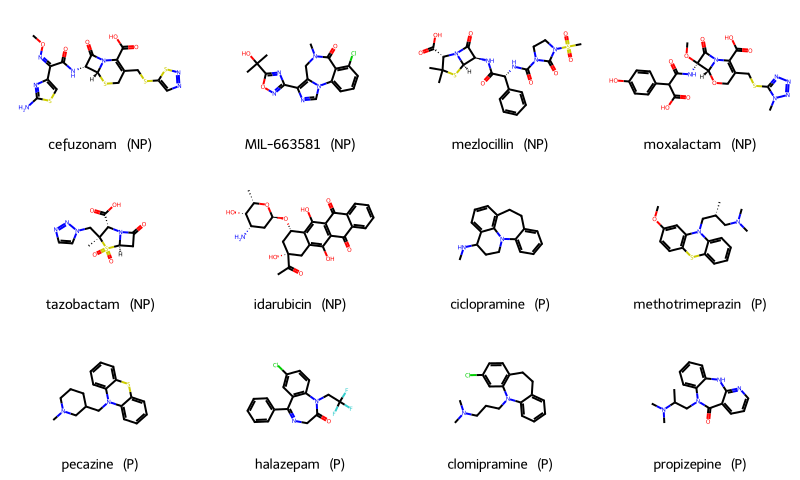

In [3]:
grid_path = save_molecule_grid(bundle.frame, bundle.y, FIGURES / "bbbp_mol_grid.png")
display(Image(filename=str(grid_path)))


## 4. Features: Morgan bits → 4 angles

Each molecule starts as a 2 048-bit Morgan fingerprint. We keep the 24 training bits with the highest mutual information, project them with PCA to **4 components**, and min–max scale those components into $[0, \pi]$ so they are legal ZZ-feature-map angles.

That is a severe bottleneck on purpose. Four numbers cannot carry a medicinal chemist’s mental model of BBB transport (lipophilicity, TPSA, efflux, molecular weight…). They can carry enough contrast, on this curated slice, for a kernel SVM to draw a readable decision surface.


In [4]:
print("train features", bundle.X_train.shape, "test features", bundle.X_test.shape)
print("selected bit indices (train MI):", bundle.compressor.bit_indices_.tolist())
print("explained variance ratio:", np.round(bundle.compressor.explained_variance_ratio_, 3))
print("feature range [min, max]:", float(bundle.features.min()), float(bundle.features.max()))
print()
print("first 5 training rows (4 PCA angles):")
print(np.round(bundle.X_train[:5], 3))


train features (75, 4) test features (25, 4)
selected bit indices (train MI): [352, 650, 2030, 1381, 1279, 492, 83, 1463, 2043, 1482, 1640, 812, 1525, 875, 970, 105, 52, 588, 314, 1647, 807, 1019, 1152, 1295]
explained variance ratio: [0.466 0.114 0.099 0.081]
feature range [min, max]: -0.02851731425078885 3.1415926535897953

first 5 training rows (4 PCA angles):
[[1.321 0.848 2.551 2.171]
 [0.    1.307 0.703 1.367]
 [0.302 1.32  1.26  1.896]
 [2.25  1.379 0.736 2.936]
 [2.462 2.38  0.837 2.74 ]]


## 5. Feature map

The circuit is Qiskit’s current `zz_feature_map` (the 2.x replacement for the old `ZZFeatureMap` class): Hadamards, data-dependent phase gates, and linear ZZ entangling phases, two repetitions, four qubits.

$$
U_{\mathrm{ZZ}}(x) = \Biggl(\prod_{i} H_i \prod_{i} e^{i x_i Z_i} \prod_{\langle i,j\rangle} e^{i x_i x_j Z_i Z_j}\Biggr)^{\!2}
$$

Aer will prepare $|\phi(x)\rangle = U_{\mathrm{ZZ}}(x)|0\rangle^{\otimes 4}$ as an exact 16-amplitude statevector.


## 6. Kernel and QSVC

`QSVC` is scikit-learn’s `SVC` with `quantum_kernel=` instead of `kernel="rbf"`. We fit it on the 75 training vectors, then score the 25 held-out molecules.

A classical RBF SVM is trained on the **same four PCA angles** so the metrics table has an honest same-representation baseline. If the two models are close, that is expected: the quantum part is the kernel, not a larger chemistry stack.


backend  aer_simulator_statevector
cached statevectors 51
train kernel (75, 75)   test-train kernel (25, 75)

QSVC  acc=0.840  AUC=0.936  F1=0.846  P=0.846  R=0.846  (21/25)
RBF   acc=0.880  AUC=0.987  F1=0.880
confusion matrix (rows=true 0/1, cols=pred 0/1):
[[10  2]
 [ 2 11]]


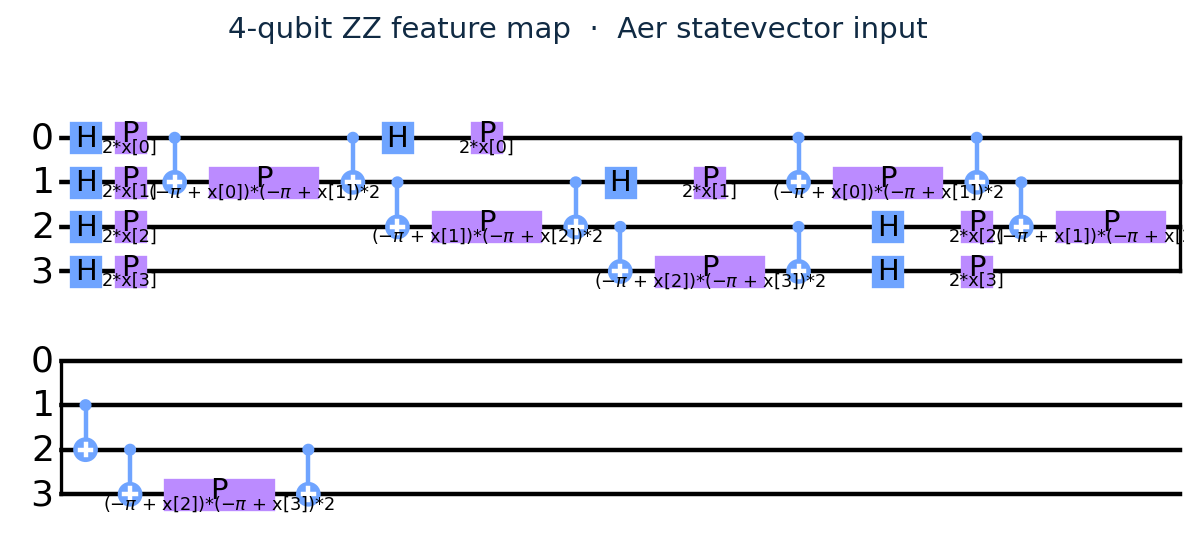

In [5]:
fit = fit_quantum_kernel_qsvc(
    bundle.X_train,
    bundle.y_train,
    bundle.X_test,
    bundle.y_test,
    seed=int(bundle.curation["seed"]),
)
neighbor_idx, neighbor_label = nearest_train_neighbors(fit.k_test, bundle.y_train)

print("backend ", fit.kernel.backend_name)
print("cached statevectors", len(fit.kernel._cache))
print("train kernel", fit.k_train.shape, "  test-train kernel", fit.k_test.shape)
print()
print("QSVC  acc={accuracy:.3f}  AUC={auc:.3f}  F1={f1:.3f}  P={precision:.3f}  R={recall:.3f}  ({n_correct}/{n_test})".format(**fit.metrics))
print("RBF   acc={accuracy:.3f}  AUC={auc:.3f}  F1={f1:.3f}".format(**fit.classical_metrics))
print("confusion matrix (rows=true 0/1, cols=pred 0/1):")
print(np.asarray(fit.metrics["confusion_matrix"]))

fm_path = save_feature_map(fit.kernel.feature_map, FIGURES / "bbbp_feature_map.png")
display(Image(filename=str(fm_path)))


## 7. Results

Kernel heatmaps are sorted by label so any class block-structure is visible. The ROC and confusion matrix are the 25-molecule test split only.


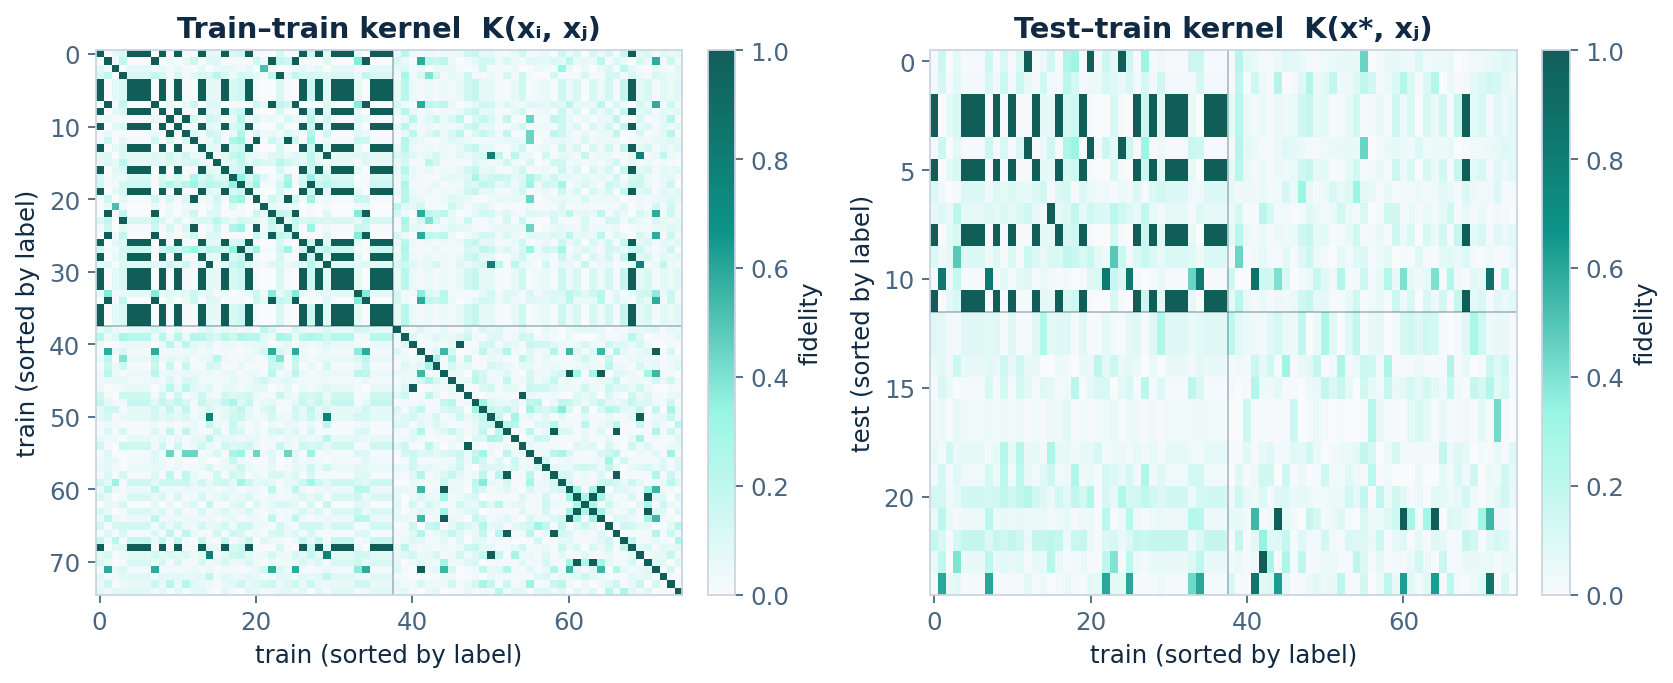

In [6]:
heat_path = save_kernel_heatmaps(
    fit.k_train, fit.k_test, bundle.y_train, bundle.y_test, FIGURES / "bbbp_kernel_heatmaps.png"
)
display(Image(filename=str(heat_path)))


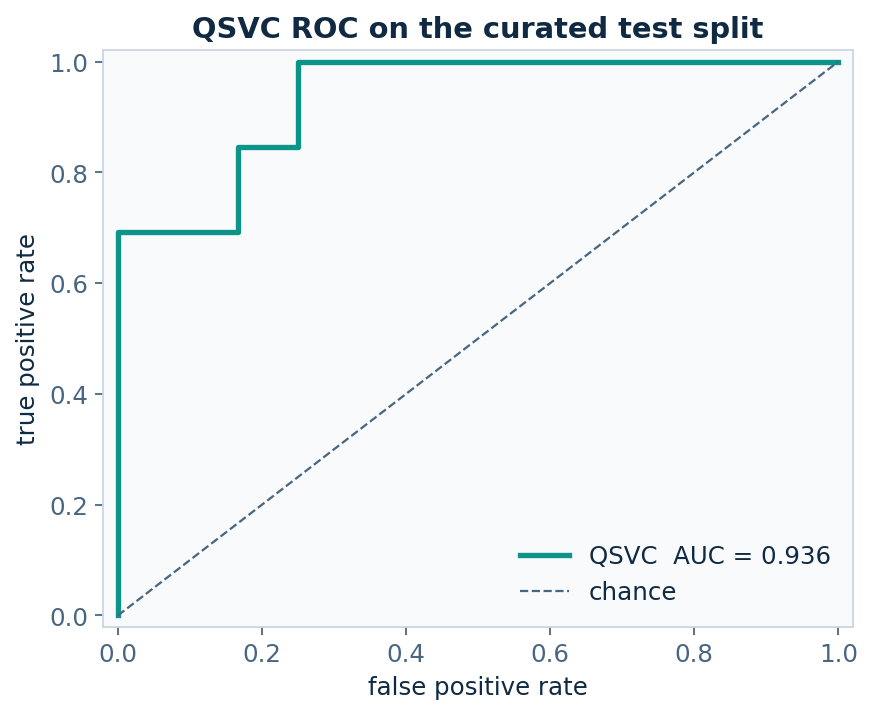

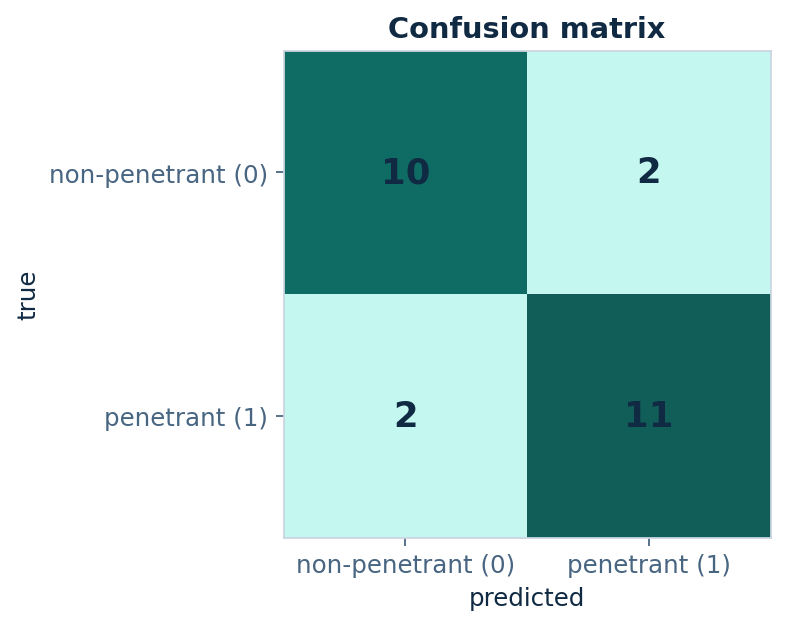

In [7]:
roc_path = save_roc_curve(fit.metrics, FIGURES / "bbbp_roc.png")
cm_path = save_confusion_matrix(fit.metrics, FIGURES / "bbbp_confusion_matrix.png")
display(Image(filename=str(roc_path)))
display(Image(filename=str(cm_path)))


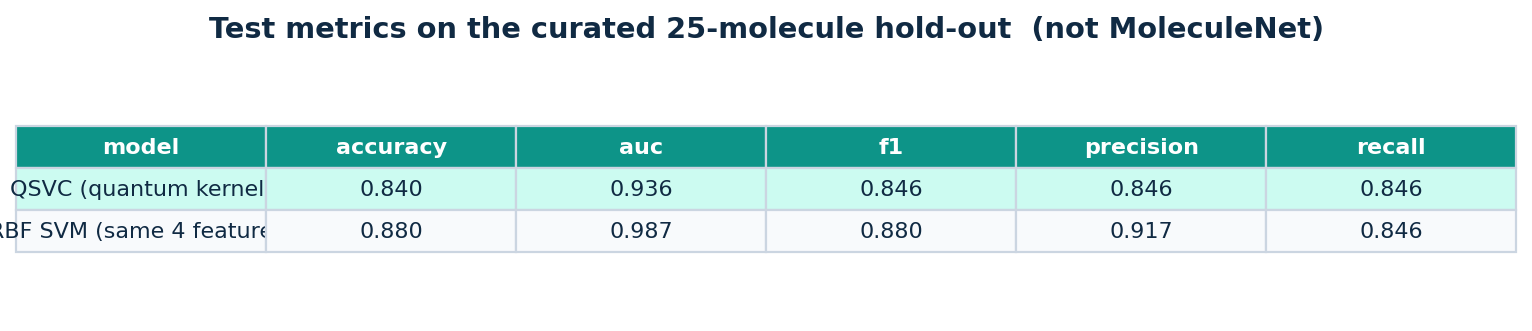

In [8]:
metrics_path = save_metrics_table(fit.metrics, fit.classical_metrics, FIGURES / "bbbp_metrics_table.png")
display(Image(filename=str(metrics_path)))


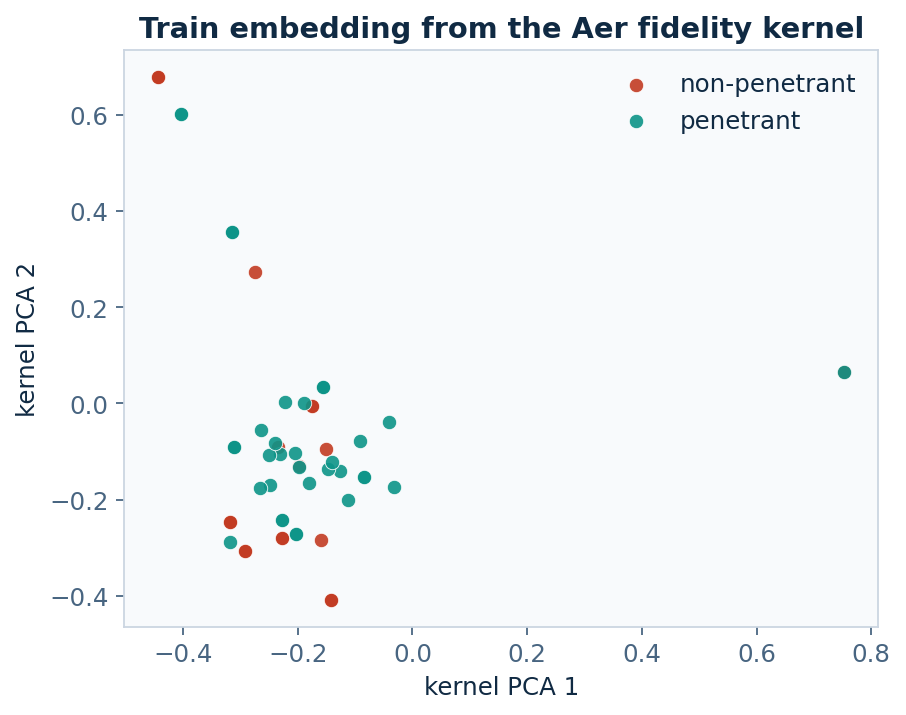

In [9]:
emb_path = save_kernel_embedding(fit.k_train, bundle.y_train, FIGURES / "bbbp_kernel_embedding.png")
display(Image(filename=str(emb_path)))


### Predictions

Every test molecule, then a strip of structures (errors first). Decision scores are the QSVC signed distance to the margin — not a calibrated probability.


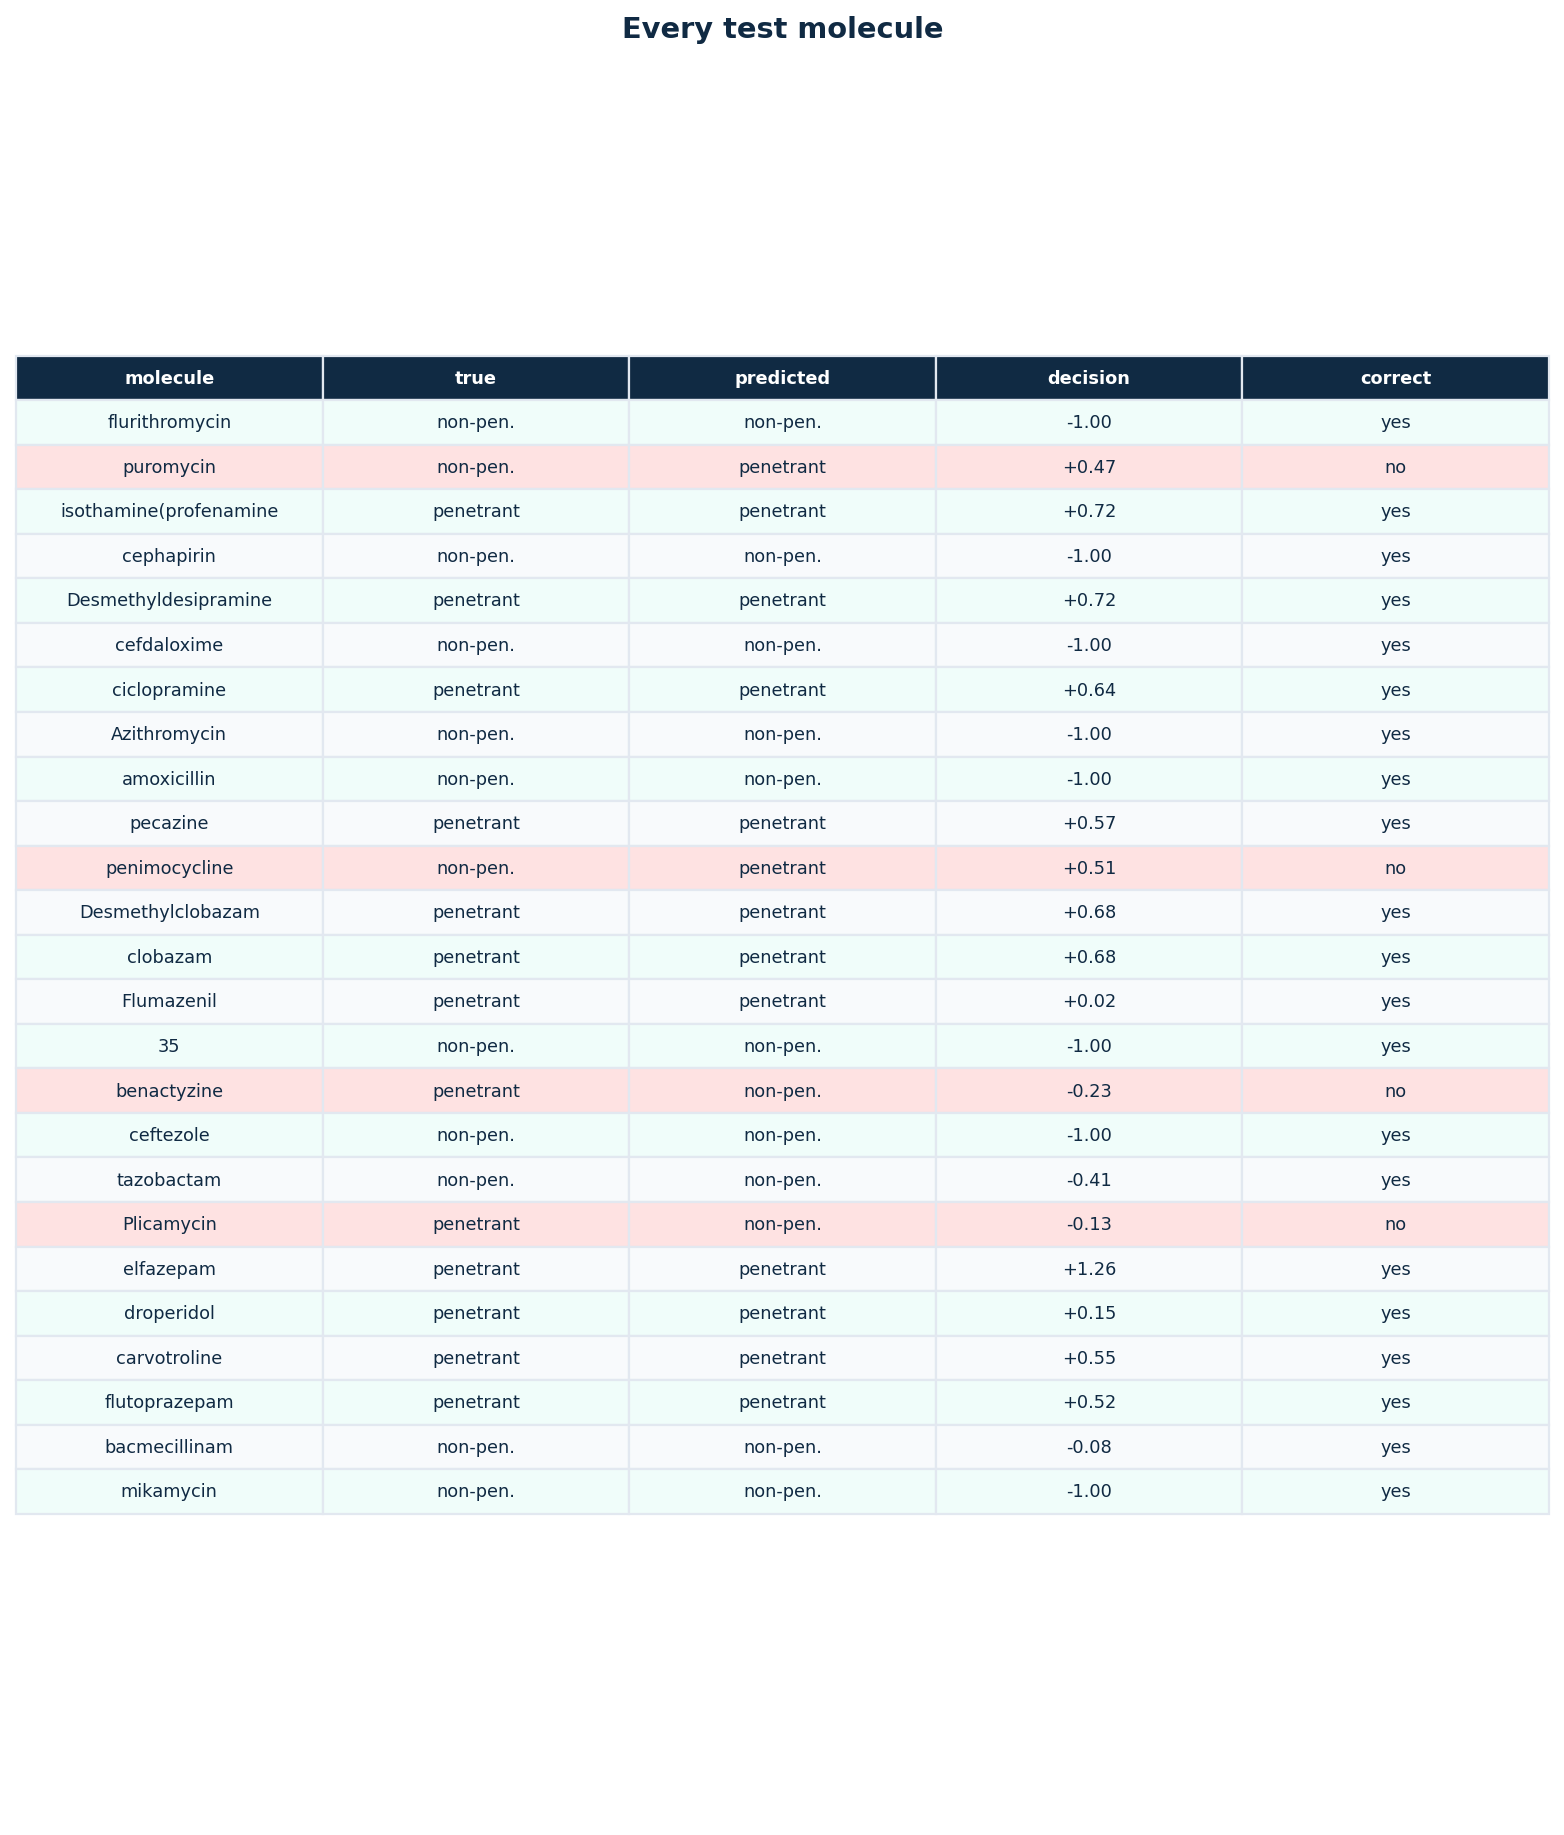

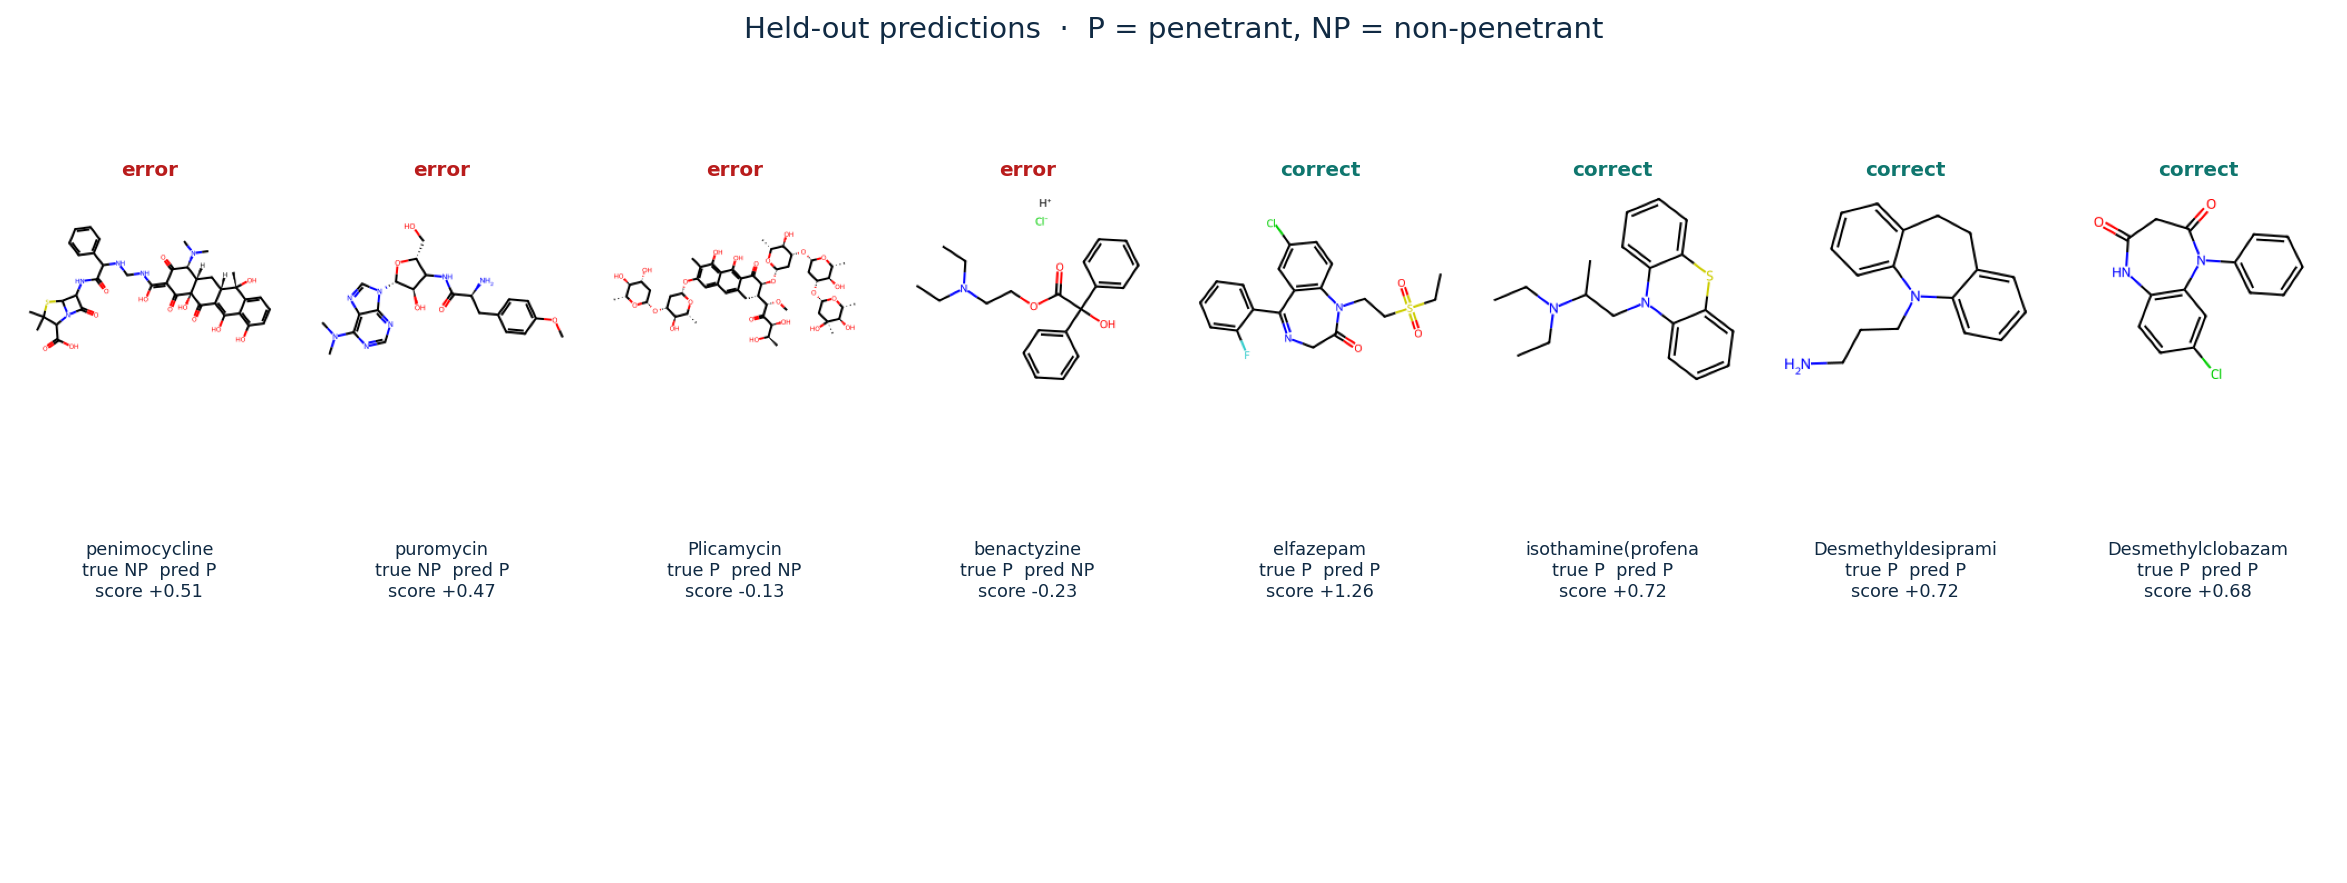

In [10]:
table_path = save_prediction_table(
    bundle.test_frame, bundle.y_test, fit.y_pred, fit.y_score, FIGURES / "bbbp_prediction_table.png"
)
ex_path = save_prediction_examples(
    bundle.test_frame, bundle.y_test, fit.y_pred, fit.y_score, FIGURES / "bbbp_prediction_examples.png"
)
display(Image(filename=str(table_path)))
display(Image(filename=str(ex_path)))


### Structures and similarity maps

For selected correct and incorrect test molecules we take the **nearest training neighbor under the quantum kernel** and draw an RDKit Morgan similarity map of the test structure versus that neighbor. Green-leaning atom highlights increase fingerprint similarity to the neighbor; magenta-leaning highlights decrease it.

These maps explain *chemical* neighborhood in the fingerprint sense. They do not explain the 4-qubit circuit.


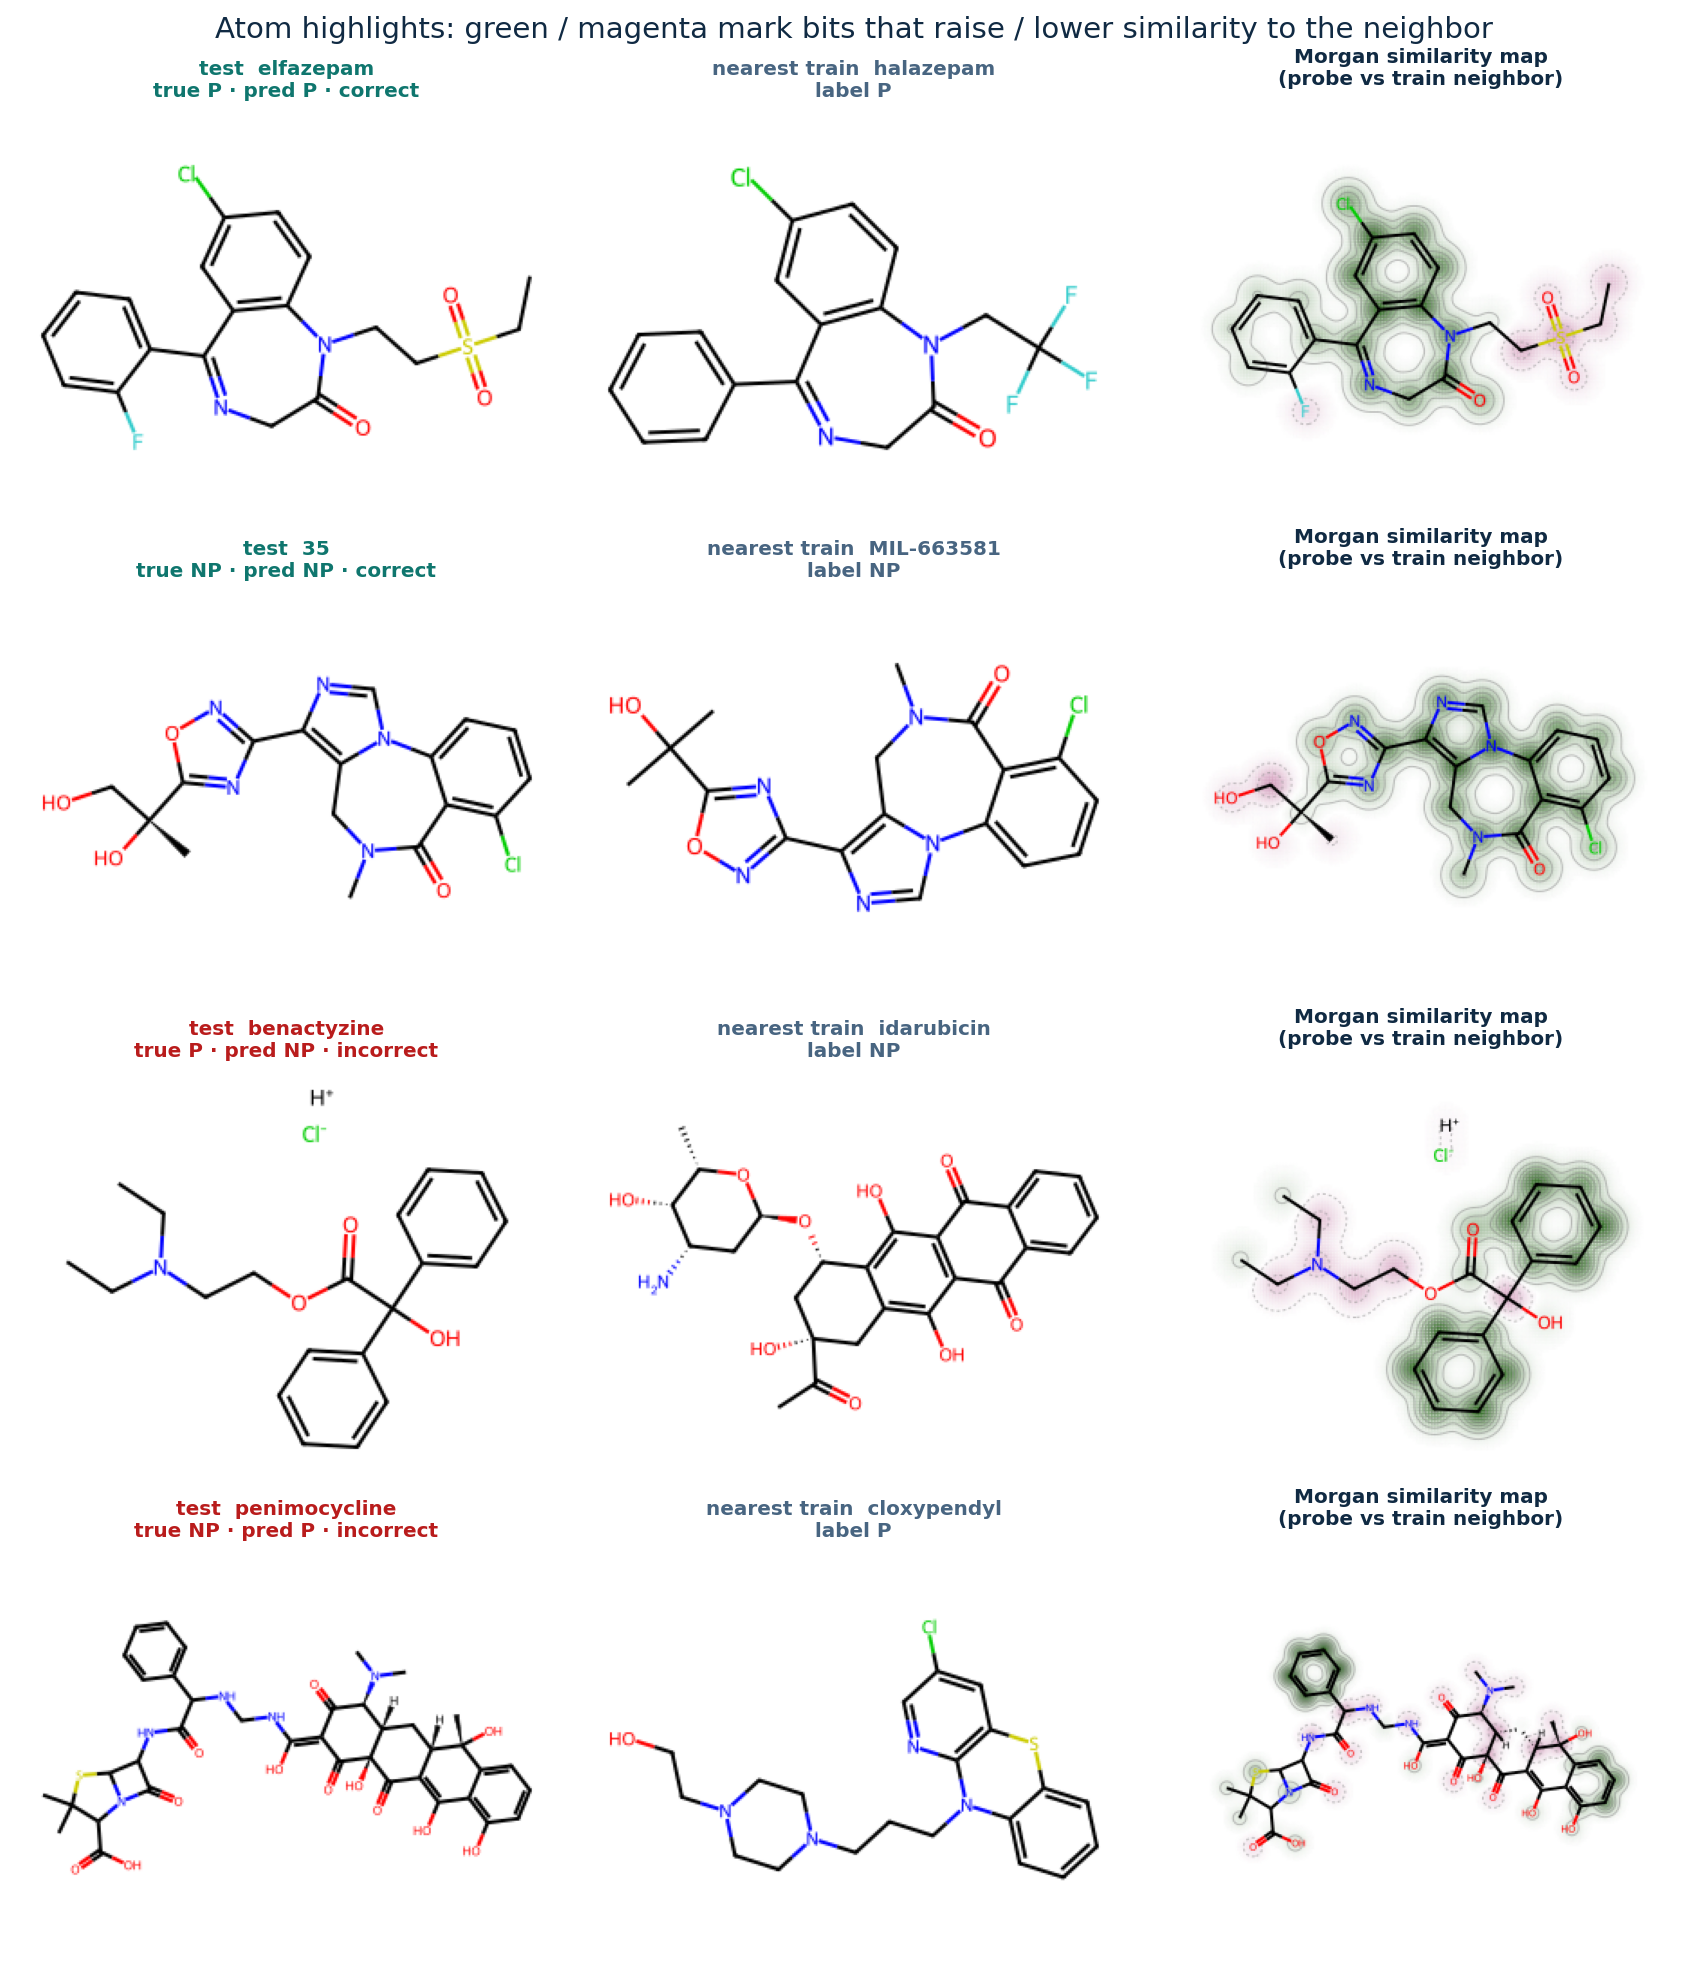

In [11]:
sim_path = save_similarity_maps(
    bundle.test_frame,
    bundle.train_frame,
    bundle.y_test,
    fit.y_pred,
    fit.y_score,
    neighbor_idx,
    FIGURES / "bbbp_similarity_maps.png",
)
display(Image(filename=str(sim_path)))


## 8. Why this maps (carefully) to drug-discovery / BBB work

BBB penetration is a real early ADME question, and binary labels on public SMILES are how a lot of QSAR papers start. A quantum kernel SVM is a compact way to study that *shape* of problem — embed descriptors, compare pairs, classify — while every amplitude still fits in 16 complex numbers.

That is the whole analogy. This notebook is **not**:

- a claim that QSVC outperforms ECFP + SVM, graph nets, or foundation models on full BBBP,
- a replacement for permeability assays, P-gp efflux assays, or CNS MPO scoring, or
- evidence of near-term quantum advantage.

Four simulated qubits cannot encode a drug-like molecule. The transferable piece is the workflow: curate a discrete representation honestly, fit a kernel model, and report accuracy / AUC on a held-out slice *while stating how the slice was built*.


## References

1. Havlíček, V. *et al.* Supervised learning with quantum-enhanced feature spaces. *Nature* **567**, 209–212 (2019).
2. Martins, I. F. *et al.* A Bayesian approach to *in silico* blood-brain barrier penetration modeling. *J. Chem. Inf. Model.* **52**, 1686–1697 (2012).
3. Wu, Z. *et al.* MoleculeNet: a benchmark for molecular machine learning. *Chem. Sci.* **9**, 513–530 (2018).
4. [Qiskit Machine Learning — QSVC](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.QSVC.html).
5. DeepChem BBBP dump: `https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv`.
